# KNN Classification 
## LAB 5


### Data Loading and Initial Exploration

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

digits = load_digits()
X = pd.DataFrame(digits.data)
y = pd.Series(digits.target, name="target")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass counts:\n", y.value_counts().sort_index())

X shape: (1797, 64)
y shape: (1797,)

Class counts:
 target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


### Exploratory Data Analysis (EDA)

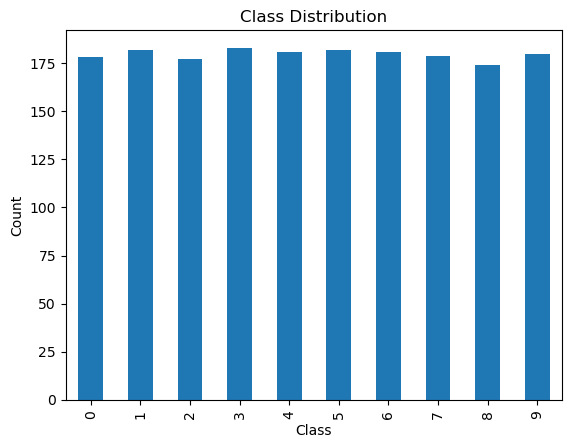

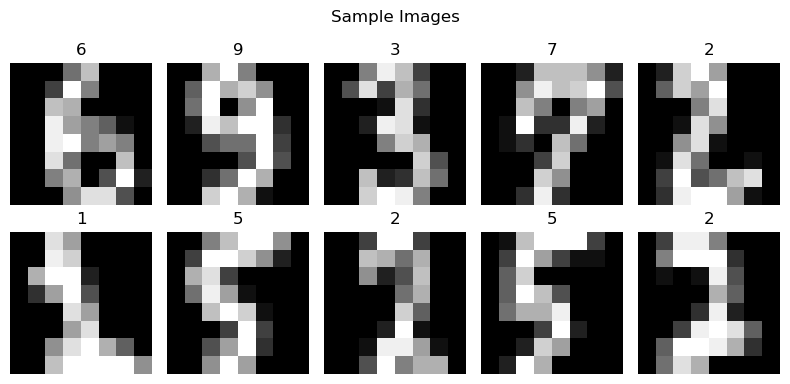

In [27]:
plt.figure()
y.value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# sample images
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X), size=10, replace=False)

plt.figure(figsize=(8, 4))
for i, idx in enumerate(sample_idx, 1):
    plt.subplot(2, 5, i)
    plt.imshow(digits.images[idx], cmap="gray")
    plt.title(int(y.iloc[idx]))
    plt.axis("off")
plt.suptitle("Sample Images")
plt.tight_layout()
plt.show()

### Feature Scaling

In [21]:
X_fe = X.copy()

X_fe["pixel_sum"] = X.sum(axis=1)
X_fe["pixel_mean"] = X.mean(axis=1)
X_fe["pixel_std"] = X.std(axis=1)

X_fe.columns = X_fe.columns.astype(str)

print("Original shape:", X.shape)
print("After feature engineering:", X_fe.shape)

Original shape: (1797, 64)
After feature engineering: (1797, 67)


### Train-Test Split (Stratified)

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.2, random_state=42, stratify=y
)

print("Train class counts:\n", y_train.value_counts().sort_index())
print("\nTest class counts:\n", y_test.value_counts().sort_index())

Train class counts:
 target
0    142
1    146
2    142
3    146
4    145
5    145
6    145
7    143
8    139
9    144
Name: count, dtype: int64

Test class counts:
 target
0    36
1    36
2    35
3    37
4    36
5    37
6    36
7    36
8    35
9    36
Name: count, dtype: int64


### Handling Class Imbalance (Simple Random Oversampling)

In [23]:
from sklearn.utils import resample

def random_oversample(X_tr, y_tr, random_state=42):
    df = X_tr.copy()
    df["target"] = y_tr.values

    class_counts = df["target"].value_counts()
    max_count = class_counts.max()

    parts = []
    for cls in class_counts.index:
        cls_df = df[df["target"] == cls]
        cls_up = resample(cls_df, replace=True, n_samples=max_count, random_state=random_state)
        parts.append(cls_up)

    up = pd.concat(parts).sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    y_up = up["target"]
    X_up = up.drop(columns=["target"])
    return X_up, y_up

X_train_bal, y_train_bal = random_oversample(X_train, y_train, random_state=42)

print("Before balancing:\n", y_train.value_counts().sort_index())
print("\nAfter balancing:\n", y_train_bal.value_counts().sort_index())

Before balancing:
 target
0    142
1    146
2    142
3    146
4    145
5    145
6    145
7    143
8    139
9    144
Name: count, dtype: int64

After balancing:
 target
0    146
1    146
2    146
3    146
4    146
5    146
6    146
7    146
8    146
9    146
Name: count, dtype: int64


### Scaling + Hyperparameter Tuning (GridSearchCV with Stratified 5-Fold)

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(algorithm="brute"))
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "minkowski", "cosine"],
    "knn__p": [1, 2, 3],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_bal, y_train_bal)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_model = grid.best_estimator_

Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV accuracy: 0.9917808219178081


### Decision Boundary Visualization (2D PCA Projection)

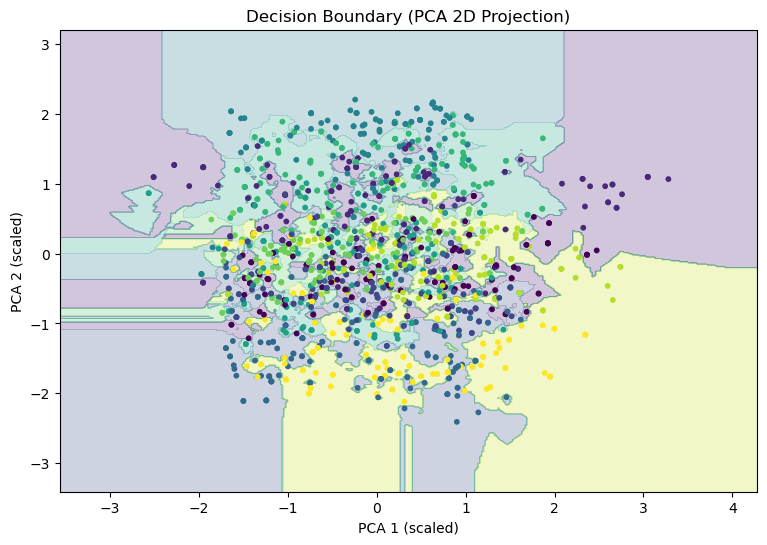

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_bal)
X_test_2d = pca.transform(X_test)

sc2 = StandardScaler()
X_train_2d_s = sc2.fit_transform(X_train_2d)
X_test_2d_s = sc2.transform(X_test_2d)

best_knn_params = {k.replace("knn__", ""): v for k, v in grid.best_params_.items()}
knn_2d = KNeighborsClassifier(**best_knn_params, algorithm="brute")
knn_2d.fit(X_train_2d_s, y_train_bal)

x_min, x_max = X_train_2d_s[:, 0].min() - 1, X_train_2d_s[:, 0].max() + 1
y_min, y_max = X_train_2d_s[:, 1].min() - 1, X_train_2d_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X_train_2d_s[:, 0], X_train_2d_s[:, 1], c=y_train_bal, s=10)
plt.title("Decision Boundary (PCA 2D Projection)")
plt.xlabel("PCA 1 (scaled)")
plt.ylabel("PCA 2 (scaled)")
plt.show()

### Model Evaluation (Confusion Matrix + Classification Report)

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

Confusion Matrix:
 [[35  0  0  0  1  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 36  0  0  0  1]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  6  1  0  0  1  1  0 25  1]
 [ 0  0  0  0  1  0  0  1  1 33]]

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    0.9722    0.9859        36
           1     0.8571    1.0000    0.9231        36
           2     0.9722    1.0000    0.9859        35
           3     1.0000    1.0000    1.0000        37
           4     0.9474    1.0000    0.9730        36
           5     0.9730    0.9730    0.9730        37
           6     0.9730    1.0000    0.9863        36
           7     0.9730    1.0000    0.9863        36
           8     0.9615    0.7143    0.8197        35
           9     0.9429    0.9167    0.9296        36

    accuracy                 